画斜二测
---

In [ ]:
import numpy as np
import tifffile as tiff
import pyvista as pv


def render_oblique_stack(
    input_tif,
    output_png="oblique_view.png",
    spacing=(1.0, 1.0, 3.0),   # (sx, sy, sz)，如果 zRatio=3，就设成 (1,1,3)
    pmin=1.0,                  # 强度归一化下限百分位
    pmax=99.5,                 # 强度归一化上限百分位
    display_min=0.08,          # 低于这个值的信号压背景
    window_size=(1200, 1200),
    zoom=1.2,
):
    """
    输入:
        input_tif: 3D tif 文件路径，默认假设 shape = (Z, Y, X)
        output_png: 输出图片路径
        spacing: 体素尺寸 (sx, sy, sz)
        pmin/pmax: 归一化分位数
        display_min: 类似 Imaris 里的 Min，用于压背景
        window_size: 导出图片大小
        zoom: 相机缩放

    输出:
        保存一张斜视角 3D stack 图
    """

    # ========= 1. 读取数据 =========
    vol = tiff.imread(input_tif).astype(np.float32).transpose(2,0,1)

    if vol.ndim != 3:
        raise ValueError(f"期望输入是 3D 数据 (Z,Y,X)，但当前 shape={vol.shape}")

    print("Input volume shape (Z,Y,X):", vol.shape)

    # ========= 2. 归一化 =========
    lo, hi = np.percentile(vol, [pmin, pmax])
    vol = np.clip((vol - lo) / (hi - lo + 1e-8), 0, 1)

    # ========= 3. 压背景 =========
    # 这一步相当于在 Imaris 里调 Min
    vol_disp = vol.copy()
    vol_disp[vol_disp < display_min] = 0.0

    # ========= 4. 构建 PyVista ImageData =========
    # PyVista 中 dimensions 顺序是 (X, Y, Z)
    z, y, x = vol_disp.shape
    sx, sy, sz = spacing

    grid = pv.ImageData()
    grid.dimensions = (x, y, z)
    grid.spacing = (sx, sy, sz)
    grid.origin = (0.0, 0.0, 0.0)

    # 数据要转成 (X,Y,Z) 对应的顺序，并按 Fortran 顺序展平
    grid.point_data["values"] = np.transpose(vol_disp, (2, 1, 0)).ravel(order="F")

    # ========= 5. 设置绘图器 =========
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("black")

    # ========= 6. 设置透明度曲线 =========
    # 低强度更透明，高强度更不透明
    # 如果你想让更多暗像素显示，就把前半段调高一点
    opacity = [0.00, 0.00, 0.01, 0.03, 0.06, 0.12, 0.22, 0.40, 0.70, 1.00]

    plotter.add_volume(
        grid,
        scalars="values",
        cmap="gray",
        opacity=opacity,
        shade=True,     # 阴影增强立体感
        ambient=0.15,
        diffuse=0.85,
        specular=0.10,
    )

    # ========= 7. 设置斜视角 / 斜二测近似视角 =========
    # 注意：严格“斜二测”是制图学概念
    # 这里我们做的是一个很接近论文里常见的 oblique 3D view
    cx = x * sx / 2.0
    cy = y * sy / 2.0
    cz = z * sz / 2.0
    center = (cx, cy, cz)

    camera_pos = (
        cx + 1.6 * x * sx,   # x 方向偏移
        cy - 1.3 * y * sy,   # y 方向偏移
        cz + 1.8 * z * sz    # z 方向抬高
    )

    plotter.camera_position = [
        camera_pos,          # 相机位置
        center,              # 看向中心
        (0, 0, 1)            # up 方向
    ]

    plotter.camera.zoom(zoom)

    # ========= 8. 导出 =========
    plotter.show(screenshot=output_png)
    plotter.close()

    print(f"Saved to: {output_png}")


if __name__ == "__main__":
    render_oblique_stack(
        input_tif="/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/1/ref.tif",
        output_png="/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/oblique_view.png",
        spacing=(1.0, 1.0, 3.0),   # 例如 zRatio=3
        pmin=1.0,
        pmax=99.5,
        display_min=0.08,
        window_size=(1200, 1200),
        zoom=1.2,
    )

In [4]:
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from scipy.ndimage import rotate


def oblique_mip(
    input_tif,
    output_png="/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/1/ref.tif",
    angle_xy=30,   # 在 XY 平面内旋转
    angle_xz=-20,  # 抬起视角
    pmin=1.0,
    pmax=99.5,
    vmin=0.05,
    vmax=0.8,
):
    vol = tiff.imread(input_tif).astype(np.float32).transpose(2,0,1)

    if vol.ndim != 3:
        raise ValueError(f"期望输入是 3D 数据 (Z,Y,X)，但当前 shape={vol.shape}")

    # 归一化
    lo, hi = np.percentile(vol, [pmin, pmax])
    vol = np.clip((vol - lo) / (hi - lo + 1e-8), 0, 1)

    # 先旋转 XY
    vol_rot = rotate(vol, angle=angle_xy, axes=(1, 2), reshape=True, order=1)

    # 再旋转 XZ / 抬起视角
    vol_rot = rotate(vol_rot, angle=angle_xz, axes=(0, 2), reshape=True, order=1)

    # 最大投影
    img = np.max(vol_rot, axis=0)

    # 保存
    plt.figure(figsize=(6, 6), facecolor="black")
    plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    plt.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(output_png, dpi=300, facecolor="black", bbox_inches="tight", pad_inches=0)
    plt.close()

    print(f"Saved to: {output_png}")


if __name__ == "__main__":
    oblique_mip(
        input_tif="/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/1/ref.tif",
        output_png="/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/oblique_mip.png",
        angle_xy=30,
        angle_xz=-20,
        pmin=1.0,
        pmax=99.5,
        vmin=0.05,
        vmax=0.8,
    )

Saved to: /home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/oblique_mip.png


画XY方向的motion
---

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def scale_to_01(x, vmin=None, vmax=None, contrast=1.0, clip=True):
    """
    把输入缩放到 [0,1]
    contrast > 1 会增强对比
    """
    x = x.astype(np.float32)

    if vmin is None:
        vmin = np.min(x)
    if vmax is None:
        vmax = np.max(x)

    y = (x - vmin) / (vmax - vmin + 1e-8)

    if clip:
        y = np.clip(y, 0, 1)

    # contrast/gamma 风格调节
    # contrast > 1: 更强调高值
    # contrast < 1: 更平缓
    y = y ** (1.0 / contrast)

    return y

def motion_to_rb_image(
    motion_x,
    motion_y,
    vmin_x=0.0,
    vmax_x=5.0,
    vmin_y=0.0,
    vmax_y=5.0,
    contrast_x=1.0,
    contrast_y=1.0,
    use_abs=True,
    background="white",
    red_color=(1.0, 0.0, 0.0),          # y motion 的颜色
    blue_color=(0.2, 0.6, 0.9),      # x motion 的浅蓝色
):
    """
    返回 RGB 图像:
      y motion -> red_color
      x motion -> blue_color
    """
    mx = np.abs(motion_x) if use_abs else motion_x
    my = np.abs(motion_y) if use_abs else motion_y

    blue = scale_to_01(mx, vmin=vmin_x, vmax=vmax_x, contrast=contrast_x)
    red  = scale_to_01(my, vmin=vmin_y, vmax=vmax_y, contrast=contrast_y)

    h, w = motion_x.shape

    # 颜色层：不再是纯 R / 纯 B，而是两个指定颜色的加权
    color = np.zeros((h, w, 3), dtype=np.float32)
    for c in range(3):
        color[..., c] = red * red_color[c] + blue * blue_color[c]

    if background == "black":
        return np.clip(color, 0, 1)

    elif background == "white":
        alpha = np.maximum(red, blue)
        white = np.ones((h, w, 3), dtype=np.float32)

        # 避免颜色因为 alpha 叠加而变脏
        hue = np.zeros_like(color)
        mask = alpha > 1e-8
        for c in range(3):
            hue[..., c][mask] = color[..., c][mask] / np.maximum(alpha[mask], 1e-8)

        rgb = (1 - alpha)[..., None] * white + alpha[..., None] * hue
        return np.clip(rgb, 0, 1)

    else:
        raise ValueError("background must be 'white' or 'black'")

def motion_to_posneg_image(
    motion,
    vmin=0.0,
    vmax=5.0,
    contrast=1.0,
    background="white",
    pos_color=(0.10, 0.52, 0.68),
    neg_color=(0.92, 0.48, 0.18),
):
    """
    单方向 motion 可视化:
      motion > 0 -> pos_color
      motion < 0 -> neg_color
      |motion| 控制颜色强度
    """

    mag = np.abs(motion)
    alpha = scale_to_01(mag, vmin=vmin, vmax=vmax, contrast=contrast)

    pos = motion > 0
    neg = motion < 0

    h, w = motion.shape
    color = np.zeros((h, w, 3), dtype=np.float32)

    for c in range(3):
        color[..., c][pos] = pos_color[c]
        color[..., c][neg] = neg_color[c]

    if background == "black":
        rgb = alpha[..., None] * color
        return np.clip(rgb, 0, 1)

    elif background == "white":
        white = np.ones((h, w, 3), dtype=np.float32)
        rgb = (1 - alpha)[..., None] * white + alpha[..., None] * color
        return np.clip(rgb, 0, 1)

    else:
        raise ValueError("background must be 'white' or 'black'")


# ===== 使用示例 =====
# motion shape = (H, W, 2)
# motion[...,0] = x
# motion[...,1] = y

# motion_x = motion[..., 0]
# motion_y = motion[..., 1]

# rgb = motion_to_rb_image(
#     motion_x, motion_y,
#     vmin_x=0, vmax_x=3,
#     vmin_y=0, vmax_y=3,
#     contrast_x=1.2,
#     contrast_y=1.2,
#     use_abs=True,
# )

# plt.figure(figsize=(8, 8))
# plt.imshow(rgb)
# plt.axis("off")
# plt.tight_layout()
# plt.savefig("motion_rb.png", dpi=300, bbox_inches="tight", pad_inches=0)
# plt.show()

In [ ]:
import sys
import os
import tifffile
import numpy as np
from pathlib import Path

sys.path.append('/home/cyf/wbi/Virginia/code_for_paper/wholistic_registration/src/wholistic_registration')
current_dir = os.path.dirname(os.path.abspath("__file__"))
root_dir = os.path.dirname(current_dir)
sys.path.append(root_dir)
from utils import simulation
ref = tifffile.imread("/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/1/ref.tif").astype(np.float32).transpose(1,0,2)

motion1 = tifffile.imread("/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/9/motion.tif").transpose(1,0,2,3)
motion2 = tifffile.imread("/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/art_R/1/motion.tif").transpose(1,0,2,3)

motion_x1 = motion1[...,0, 0]
motion_y1 = motion1[...,0, 1]

motion_x2 = motion2[...,0, 0]
motion_y2 = motion2[...,0, 1]
# overlay
# result1 =motion_to_rb_image(
#     motion_x1, motion_y1,
#     vmin_x=0, vmax_x=8,
#     vmin_y=0, vmax_y=8,
#     contrast_x=0.6,
#     contrast_y=0.6,
#     use_abs=True,
# )
# result2 =motion_to_rb_image(
#     motion_x2, motion_y2,
#     vmin_x=0, vmax_x=12,
#     vmin_y=0, vmax_y=12,
#     contrast_x=0.6,
#     contrast_y=0.6,
#     use_abs=True,
# )
result_x1 = motion_to_posneg_image(motion_x1,vmax=10)
result_y1 = motion_to_posneg_image(motion_y1,vmax=10)
result_x2 = motion_to_posneg_image(motion_x2,vmax=10)
result_y2 = motion_to_posneg_image(motion_y2,vmax=10)

plt.figure(figsize=(8, 8))
plt.imshow(result_x1)
plt.axis("off")
plt.margins(0)
plt.tight_layout()
# plt.savefig("/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/motion_High_amp.png", dpi=600, bbox_inches="tight", pad_inches=0)

plt.figure(figsize=(8, 8))
plt.imshow(result_y1)
plt.axis("off")
plt.margins(0)
plt.tight_layout()
# plt.savefig("/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/motion_low_radius.png", dpi=600, bbox_inches="tight", pad_inches=0)

plt.figure(figsize=(8, 8))
plt.imshow(result_x2)
plt.axis("off")
plt.margins(0)
plt.tight_layout()

plt.figure(figsize=(8, 8))
plt.imshow(result_y2)
plt.axis("off")
plt.margins(0)
plt.tight_layout()

生成legend

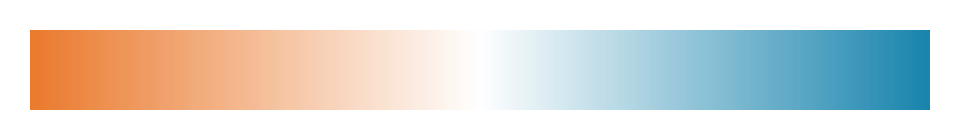

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pos_color = (0.10, 0.52, 0.68)
neg_color = (0.92, 0.48, 0.18)

def make_xymotion_legend(
    save_path=None,
    vmin=-5,
    vmax=5,
    width=900,
    height=80,
    dpi=300,
):
    """
    生成 x/y motion 正负双色渐变图例：
      negative -> neg_color
      0        -> white
      positive -> pos_color

    文字、刻度可后期自己加。
    """

    cmap = LinearSegmentedColormap.from_list(
        "motion_posneg",
        [
            (0.0, neg_color),
            (0.5, (1, 1, 1)),
            (1.0, pos_color),
        ],
        N=256,
    )

    grad = np.linspace(vmin, vmax, width)
    grad = np.tile(grad, (height, 1))

    fig_w = width / dpi
    fig_h = height / dpi

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)

    ax.imshow(
        grad,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
        origin="lower",
    )

    ax.axis("off")

    plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, transparent=True, bbox_inches="tight", pad_inches=0)

    return fig, ax


# 示例：只生成无文字图例
fig, ax = make_xymotion_legend(
    save_path=r"E:\研究生\论文准备\配准\xymotion_legend.png",
    vmin=-5,
    vmax=5,
)

plt.show()

Plot grid
---


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates


def normalize_image(img, vmin=None, vmax=None, gamma=1.0, contrast=1.0):
    """
    归一化图像到 [0, 1]，支持手动控制显示范围和对比度。
    """
    img = img.astype(np.float32)

    if vmin is None:
        vmin = np.percentile(img, 1)
    if vmax is None:
        vmax = np.percentile(img, 99)

    img = (img - vmin) / (vmax - vmin + 1e-8)
    img = np.clip(img, 0, 1)

    # 对比度
    img = np.clip(img * contrast, 0, 1)

    # gamma
    img = img ** gamma

    return img


def ray_box_intersection(x0, y0, dx, dy, xmin, xmax, ymin, ymax, eps=1e-12):
    """
    从点 (x0, y0) 沿方向 (dx, dy) 发出一条射线，
    求它与矩形边界的第一个交点。

    返回:
        (x_hit, y_hit) 或 None
    """
    ts = []

    # 与 x = xmin, xmax 相交
    if abs(dx) > eps:
        t = (xmin - x0) / dx
        if t > 0:
            y = y0 + t * dy
            if ymin - eps <= y <= ymax + eps:
                ts.append((t, xmin, y))

        t = (xmax - x0) / dx
        if t > 0:
            y = y0 + t * dy
            if ymin - eps <= y <= ymax + eps:
                ts.append((t, xmax, y))

    # 与 y = ymin, ymax 相交
    if abs(dy) > eps:
        t = (ymin - y0) / dy
        if t > 0:
            x = x0 + t * dx
            if xmin - eps <= x <= xmax + eps:
                ts.append((t, x, ymin))

        t = (ymax - y0) / dy
        if t > 0:
            x = x0 + t * dx
            if xmin - eps <= x <= xmax + eps:
                ts.append((t, x, ymax))

    if len(ts) == 0:
        return None

    ts.sort(key=lambda z: z[0])
    _, x_hit, y_hit = ts[0]
    return x_hit, y_hit


def _estimate_endpoint_direction(xs, ys, at_start=True, k=5, eps=1e-12):
    """
    用前/后 k 段平均方向来估计端点切线方向。
    """
    xs = np.asarray(xs, dtype=np.float64)
    ys = np.asarray(ys, dtype=np.float64)

    n = len(xs)
    if n < 2:
        return None

    k = min(k, n - 1)

    if at_start:
        dx = np.diff(xs[:k+1])
        dy = np.diff(ys[:k+1])
    else:
        dx = np.diff(xs[-(k+1):])
        dy = np.diff(ys[-(k+1):])

    dx_mean = np.mean(dx)
    dy_mean = np.mean(dy)

    norm = np.hypot(dx_mean, dy_mean)
    if norm < eps:
        return None

    return dx_mean, dy_mean


def extend_polyline_to_box(xs, ys, xmin, xmax, ymin, ymax, k=5):
    """
    将一条 polyline 的首尾两端沿切线方向延长到矩形边界。
    """
    xs = np.asarray(xs, dtype=np.float64)
    ys = np.asarray(ys, dtype=np.float64)

    if len(xs) < 2:
        return xs, ys

    xs_new = xs.copy()
    ys_new = ys.copy()

    # 起点：沿反方向延长
    d0 = _estimate_endpoint_direction(xs_new, ys_new, at_start=True, k=k)
    if d0 is not None:
        dx0, dy0 = d0
        start_hit = ray_box_intersection(
            xs_new[0], ys_new[0],
            -dx0, -dy0,
            xmin, xmax, ymin, ymax
        )
        if start_hit is not None:
            xs_new = np.insert(xs_new, 0, start_hit[0])
            ys_new = np.insert(ys_new, 0, start_hit[1])

    # 终点：沿正方向延长
    d1 = _estimate_endpoint_direction(xs_new, ys_new, at_start=False, k=k)
    if d1 is not None:
        dx1, dy1 = d1
        end_hit = ray_box_intersection(
            xs_new[-1], ys_new[-1],
            dx1, dy1,
            xmin, xmax, ymin, ymax
        )
        if end_hit is not None:
            xs_new = np.append(xs_new, end_hit[0])
            ys_new = np.append(ys_new, end_hit[1])

    return xs_new, ys_new


def clip_segment_to_box(x0, y0, x1, y1, xmin, xmax, ymin, ymax, eps=1e-12):
    """
    Liang-Barsky 线段裁剪。
    返回:
        None 或 (cx0, cy0, cx1, cy1)
    """
    dx = x1 - x0
    dy = y1 - y0

    p = [-dx, dx, -dy, dy]
    q = [x0 - xmin, xmax - x0, y0 - ymin, ymax - y0]

    u1, u2 = 0.0, 1.0

    for pi, qi in zip(p, q):
        if abs(pi) < eps:
            if qi < 0:
                return None
        else:
            r = qi / pi
            if pi < 0:
                if r > u2:
                    return None
                if r > u1:
                    u1 = r
            else:
                if r < u1:
                    return None
                if r < u2:
                    u2 = r

    cx0 = x0 + u1 * dx
    cy0 = y0 + u1 * dy
    cx1 = x0 + u2 * dx
    cy1 = y0 + u2 * dy
    return cx0, cy0, cx1, cy1


def clip_polyline_to_box(xs, ys, xmin, xmax, ymin, ymax, eps=1e-6):
    """
    将一条 polyline 裁剪到矩形框内。
    返回若干段可绘制的折线 [(seg_xs, seg_ys), ...]
    """
    xs = np.asarray(xs, dtype=np.float64)
    ys = np.asarray(ys, dtype=np.float64)

    segments = []
    cur_x, cur_y = [], []

    for i in range(len(xs) - 1):
        out = clip_segment_to_box(
            xs[i], ys[i], xs[i+1], ys[i+1],
            xmin, xmax, ymin, ymax
        )

        if out is None:
            if len(cur_x) >= 2:
                segments.append((np.array(cur_x), np.array(cur_y)))
            cur_x, cur_y = [], []
            continue

        x0, y0, x1, y1 = out

        if len(cur_x) == 0:
            cur_x = [x0, x1]
            cur_y = [y0, y1]
        else:
            if abs(cur_x[-1] - x0) < eps and abs(cur_y[-1] - y0) < eps:
                cur_x.append(x1)
                cur_y.append(y1)
            else:
                segments.append((np.array(cur_x), np.array(cur_y)))
                cur_x = [x0, x1]
                cur_y = [y0, y1]

    if len(cur_x) >= 2:
        segments.append((np.array(cur_x), np.array(cur_y)))

    return segments


def _draw_deformed_line(ax, x_line, y_line, motion_x, motion_y,
                        motion_scale, reverse_motion,
                        line_color, line_width, alpha,
                        xmin, xmax, ymin, ymax,
                        extend_to_boundary=True, extend_k=5):
    """
    对一条原始网格线：
    1) 按 motion 变形
    2) 首尾延长到边界
    3) 裁剪到图像框
    4) 绘制
    """
    mx = map_coordinates(motion_x, [y_line, x_line], order=1, mode='nearest')
    my = map_coordinates(motion_y, [y_line, x_line], order=1, mode='nearest')

    if reverse_motion:
        x_def = x_line - motion_scale * mx
        y_def = y_line - motion_scale * my
    else:
        x_def = x_line + motion_scale * mx
        y_def = y_line + motion_scale * my

    if extend_to_boundary:
        x_def, y_def = extend_polyline_to_box(
            x_def, y_def,
            xmin, xmax, ymin, ymax,
            k=extend_k
        )

    segments = clip_polyline_to_box(
        x_def, y_def,
        xmin, xmax, ymin, ymax
    )

    for seg_x, seg_y in segments:
        ax.plot(seg_x, seg_y, color=line_color, lw=line_width, alpha=alpha)


def plot_deformed_grid_overlay(
    img,
    motion,
    grid_step=40,
    motion_scale=1.0,
    img_vmin=None,
    img_vmax=None,
    gamma=1.0,
    contrast=1.0,
    line_color='cyan',
    line_width=1.0,
    alpha=0.9,
    figsize=(8, 8),
    save_path=None,
    dpi=300,
    reverse_motion=False,
    draw_outer_frame=False,
    extend_to_boundary=True,
    extend_k=5,
    n_samples=600,
):
    """
    在 2D 图像上绘制由 motion 变形后的网格。

    参数
    ----
    img : (H, W)
        底图
    motion : (H, W, 2)
        motion[..., 0] = x 方向位移
        motion[..., 1] = y 方向位移
    grid_step : int
        网格间距
    motion_scale : float
        形变量放大倍数
    img_vmin, img_vmax : float or None
        图像显示范围
    gamma : float
        gamma 校正
    contrast : float
        图像对比度增益
    line_color : str
        网格线颜色
    line_width : float
        网格线宽
    alpha : float
        网格线透明度
    reverse_motion : bool
        若变形方向反了，可设 True
    draw_outer_frame : bool
        是否绘制最外层边框
    extend_to_boundary : bool
        是否把每条线首尾都延长到边界
    extend_k : int
        用端点附近前/后多少段来估计切线方向
    n_samples : int
        每条线内部采样点数
    """
    if motion.ndim != 3 or motion.shape[-1] != 2:
        raise ValueError(f"motion 应该是 (H, W, 2)，当前是 {motion.shape}")

    h, w = img.shape
    motion_x = motion[..., 0]
    motion_y = motion[..., 1]

    img_show = normalize_image(
        img,
        vmin=img_vmin,
        vmax=img_vmax,
        gamma=gamma,
        contrast=contrast
    )

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_show, cmap='gray', origin='upper')
    ax.set_axis_off()

    xmin, xmax = 0, w - 1
    ymin, ymax = 0, h - 1

    # 构造原始规则网格坐标
    xs = np.arange(0, w, grid_step, dtype=np.float64)
    ys = np.arange(0, h, grid_step, dtype=np.float64)

    if len(xs) == 0 or xs[-1] != w - 1:
        xs = np.append(xs, w - 1)
    if len(ys) == 0 or ys[-1] != h - 1:
        ys = np.append(ys, h - 1)

    xs = np.unique(xs)
    ys = np.unique(ys)

    # 是否跳过最外层边框
    if draw_outer_frame:
        xs_to_draw = xs
        ys_to_draw = ys
    else:
        xs_to_draw = xs[(xs > 0) & (xs < w - 1)]
        ys_to_draw = ys[(ys > 0) & (ys < h - 1)]

    # 画横线
    for y0 in ys_to_draw:
        x_line = np.linspace(0, w - 1, n_samples, dtype=np.float64)
        y_line = np.full_like(x_line, y0, dtype=np.float64)

        _draw_deformed_line(
            ax, x_line, y_line, motion_x, motion_y,
            motion_scale, reverse_motion,
            line_color, line_width, alpha,
            xmin, xmax, ymin, ymax,
            extend_to_boundary=extend_to_boundary,
            extend_k=extend_k
        )

    # 画竖线
    for x0 in xs_to_draw:
        y_line = np.linspace(0, h - 1, n_samples, dtype=np.float64)
        x_line = np.full_like(y_line, x0, dtype=np.float64)

        _draw_deformed_line(
            ax, x_line, y_line, motion_x, motion_y,
            motion_scale, reverse_motion,
            line_color, line_width, alpha,
            xmin, xmax, ymin, ymax,
            extend_to_boundary=extend_to_boundary,
            extend_k=extend_k
        )

    ax.set_xlim(0, w - 1)
    ax.set_ylim(h - 1, 0)
    ax.set_aspect('equal')

    plt.tight_layout(pad=0)

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight', pad_inches=0)

    plt.show()

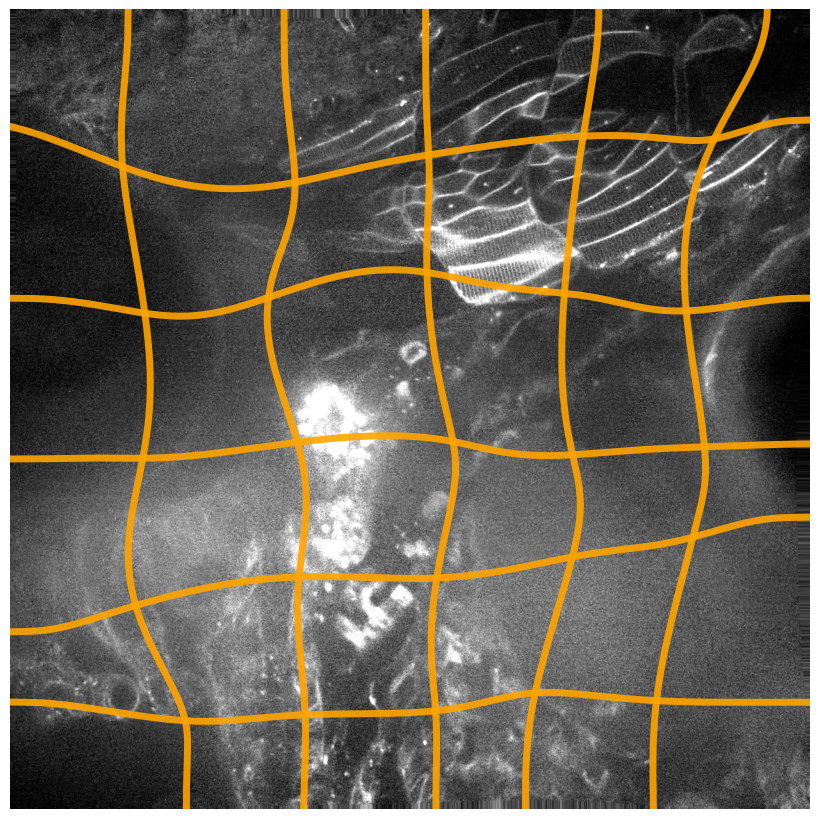

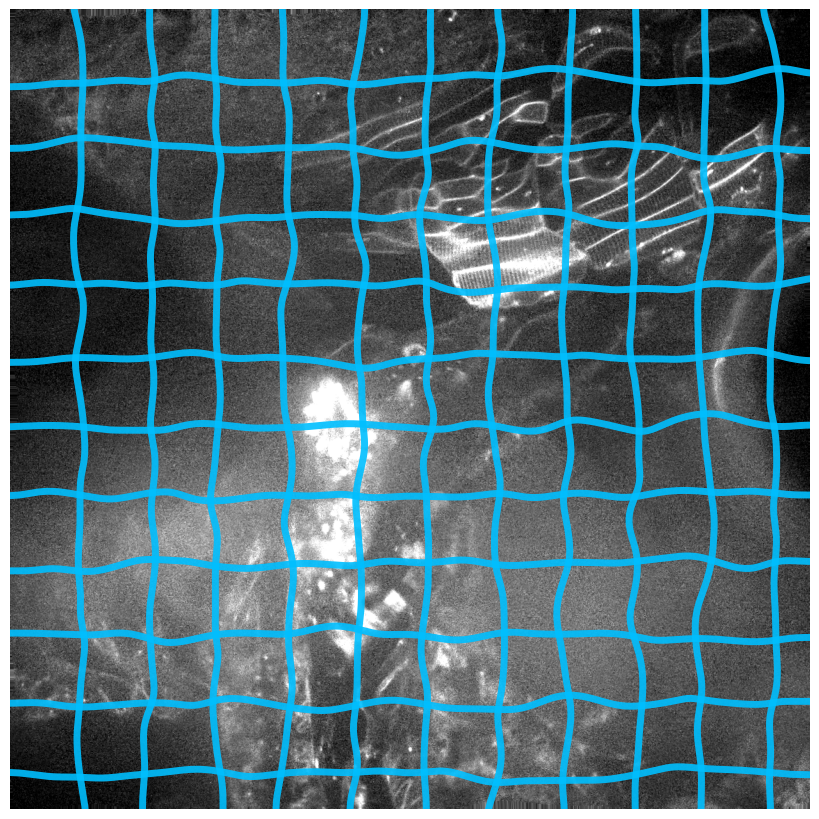

In [63]:
mov1 = tifffile.imread("/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/amp/10/mov.tif").transpose(1,0,2)
mov2 = tifffile.imread("/home/cyf/wbi/Virginia/code_for_paper/data/simulation_v0420/repos/rep01/art_R/1/mov.tif").transpose(1,0,2)
plot_deformed_grid_overlay(
    img=mov1[:,:,0],
    motion=motion1[...,0,:2],
    grid_step=200,
    motion_scale=5.0,
    gamma=1.0,
    contrast=1.0,
    line_color='orange',
    line_width=5,
    alpha=0.9,
    figsize=(8, 8),
    save_path="/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/High_amp_deformed.png",
    reverse_motion=False,
)
plot_deformed_grid_overlay(
    img=mov2[:,:,0],
    motion=motion2[...,0,:2],
    grid_step=100,
    motion_scale=1.5,
    gamma=1.0,
    contrast=1.0,
    line_color='deepskyblue',
    line_width=5,
    alpha=0.9,
    figsize=(8, 8),
    save_path="/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/Low_radius_deformed.png",
    reverse_motion=False,
)

画积分的感觉，需要展示很多个slice的motion

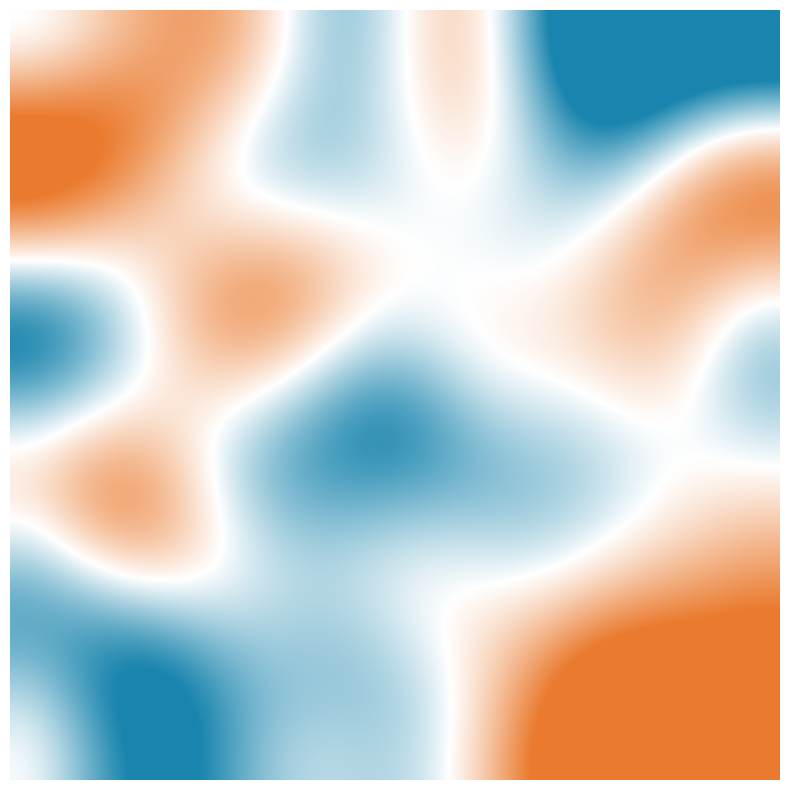

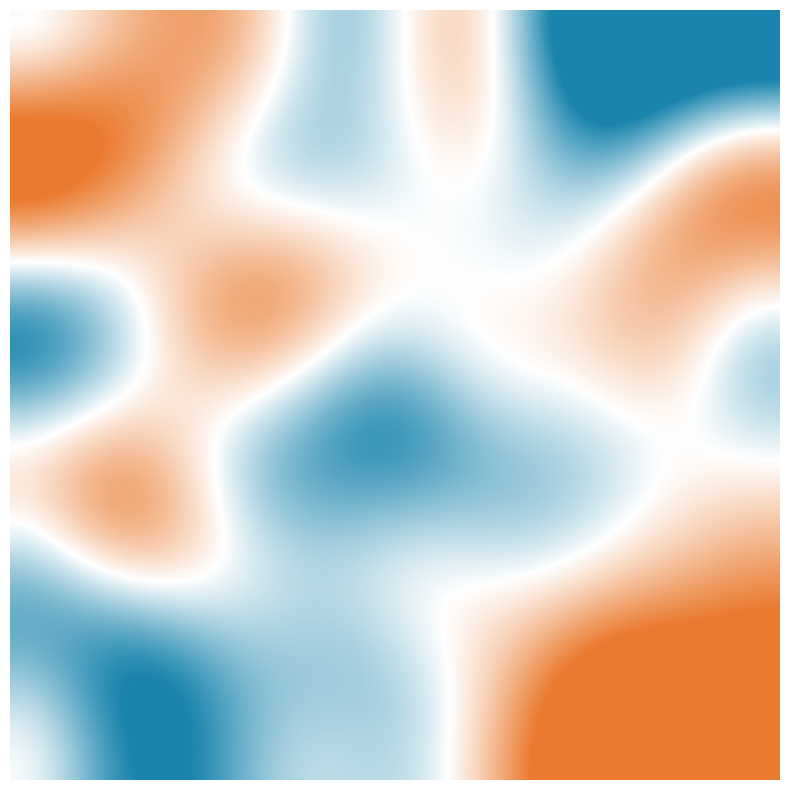

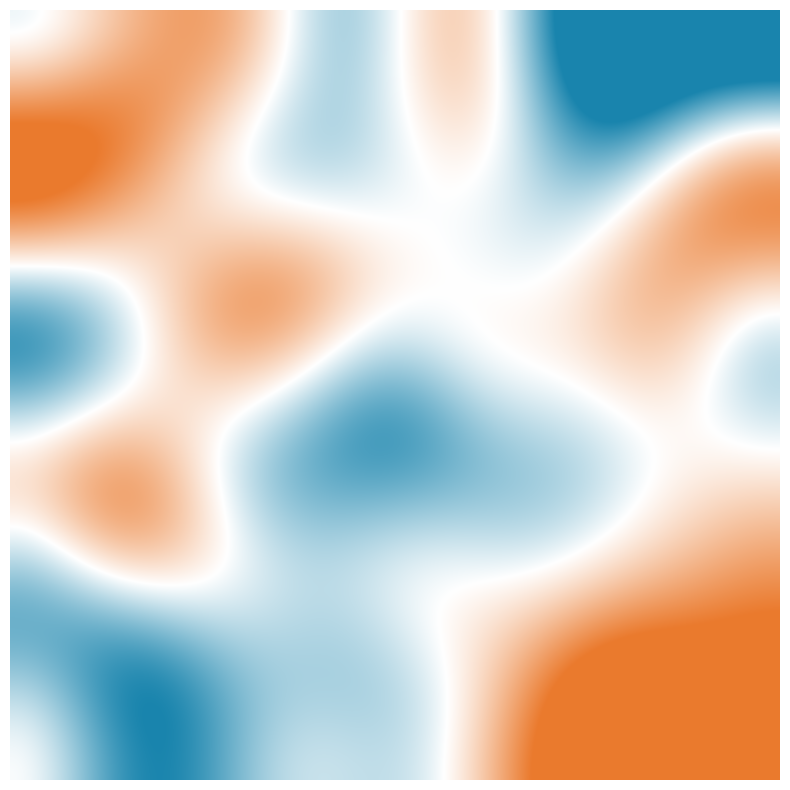

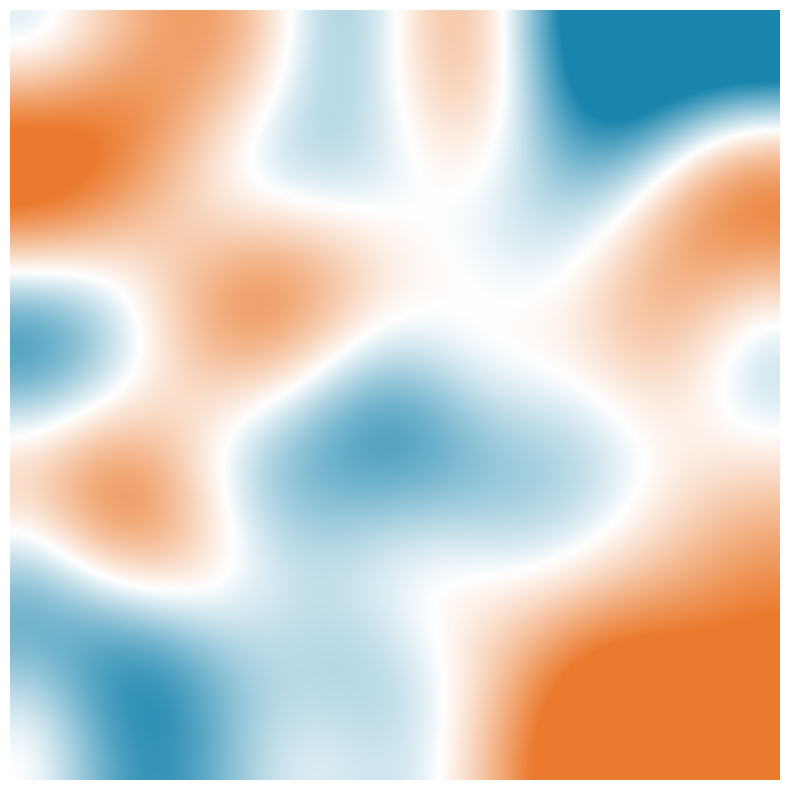

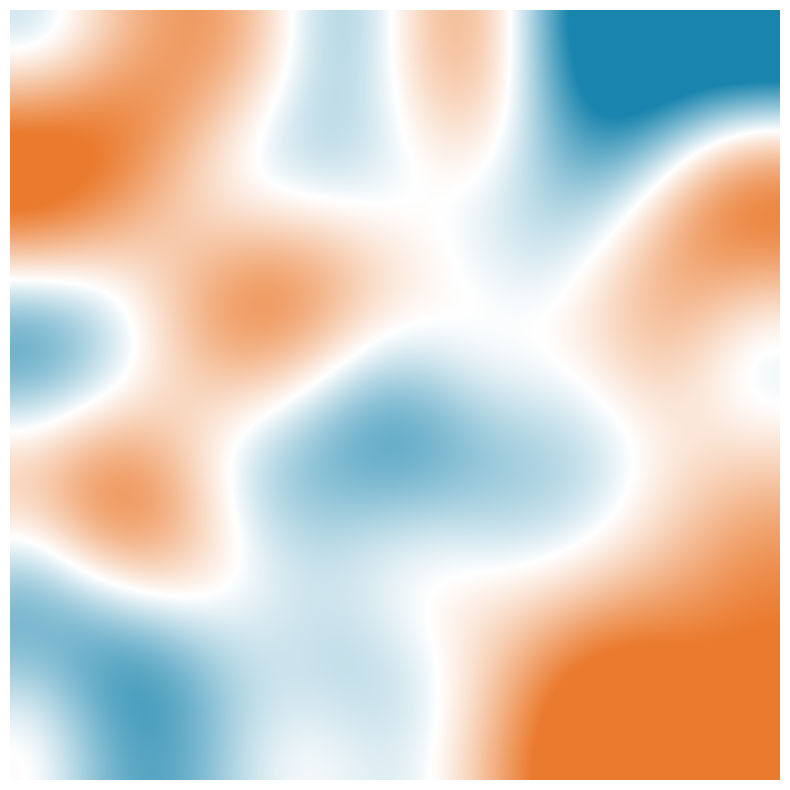

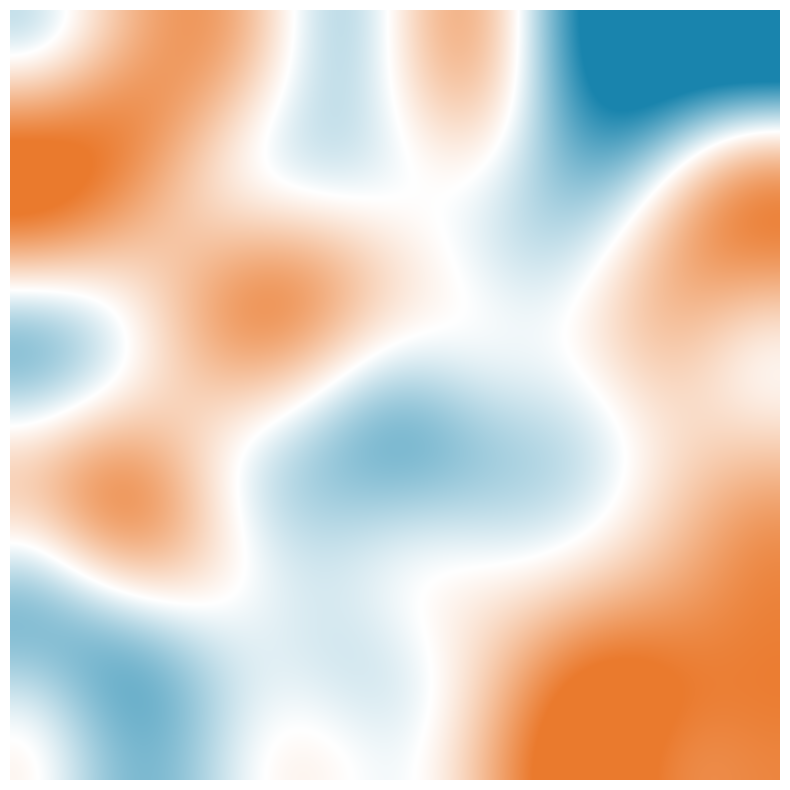

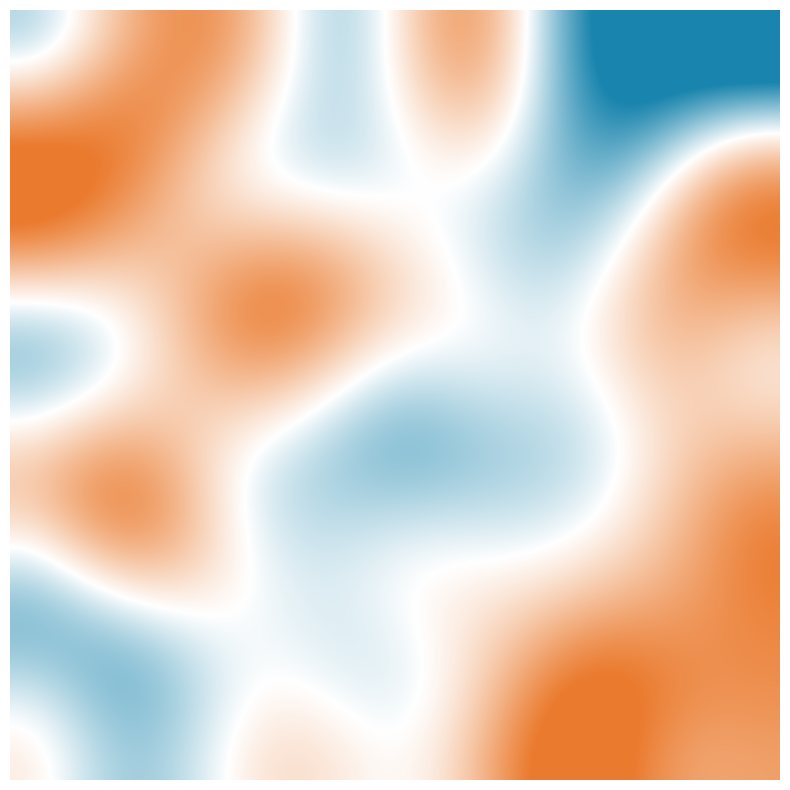

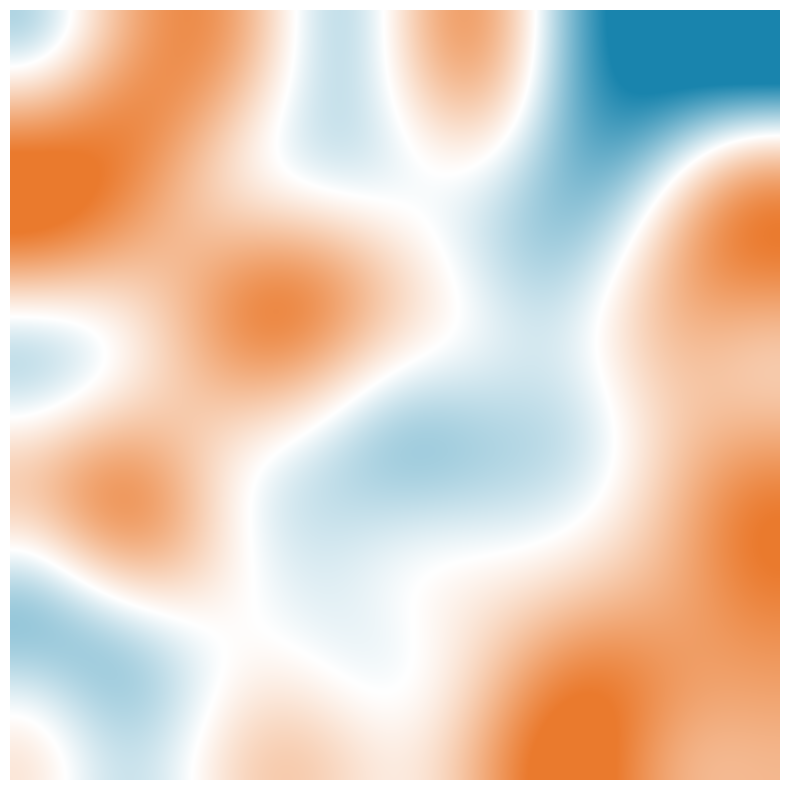

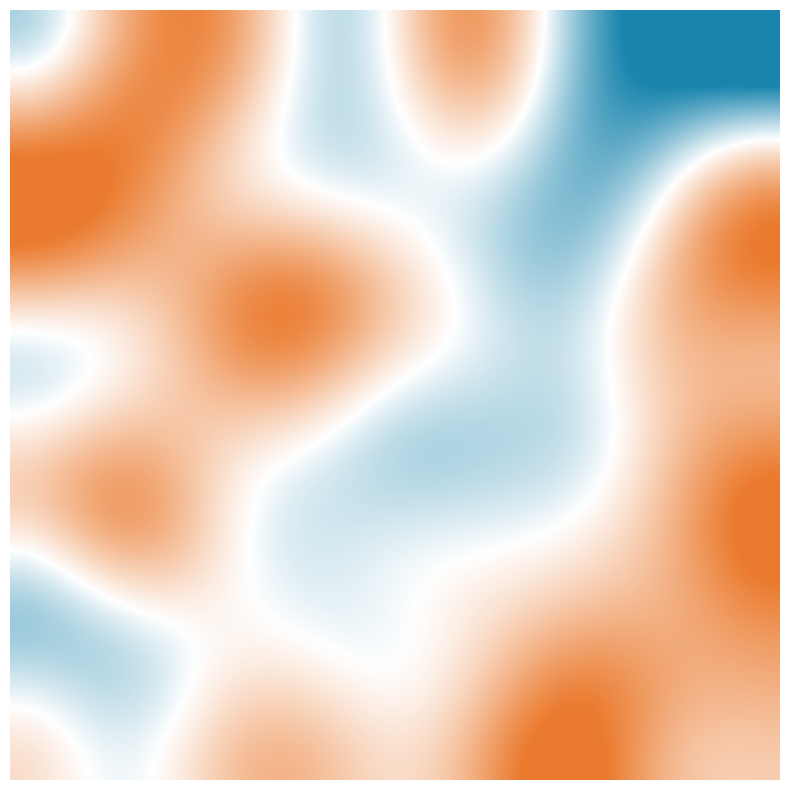

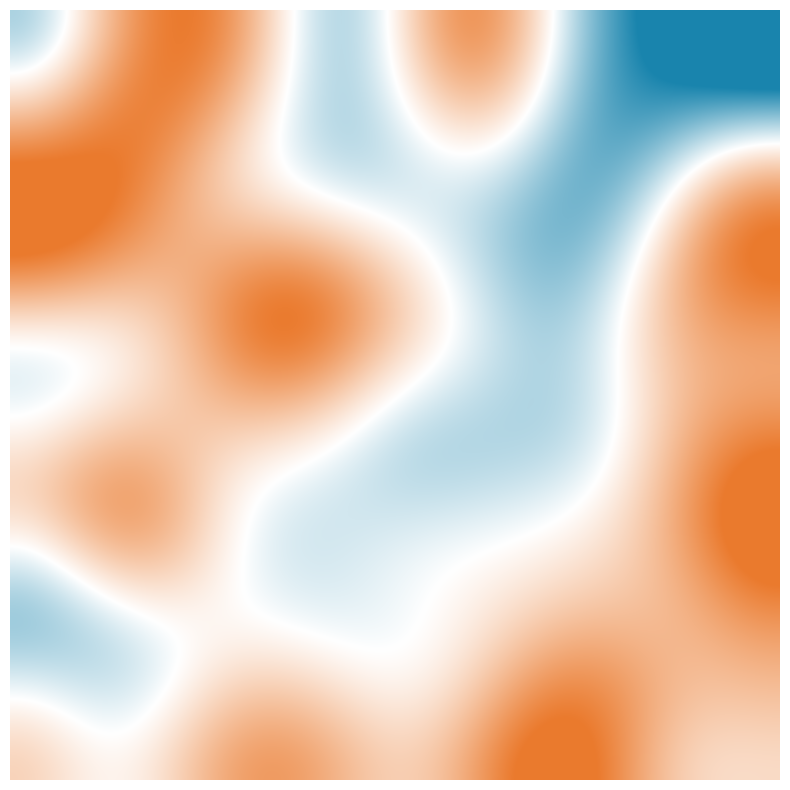

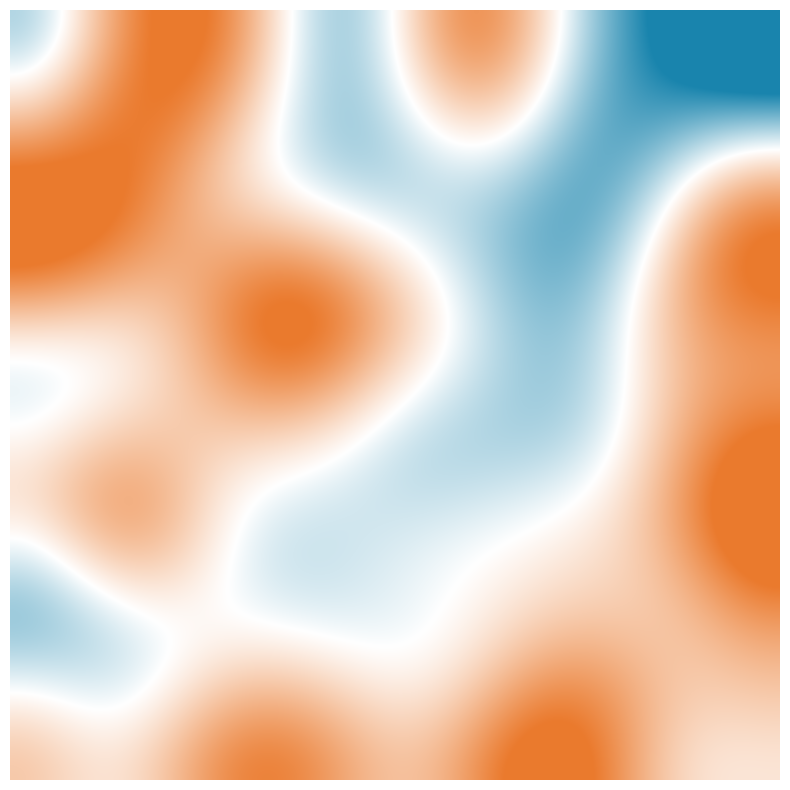

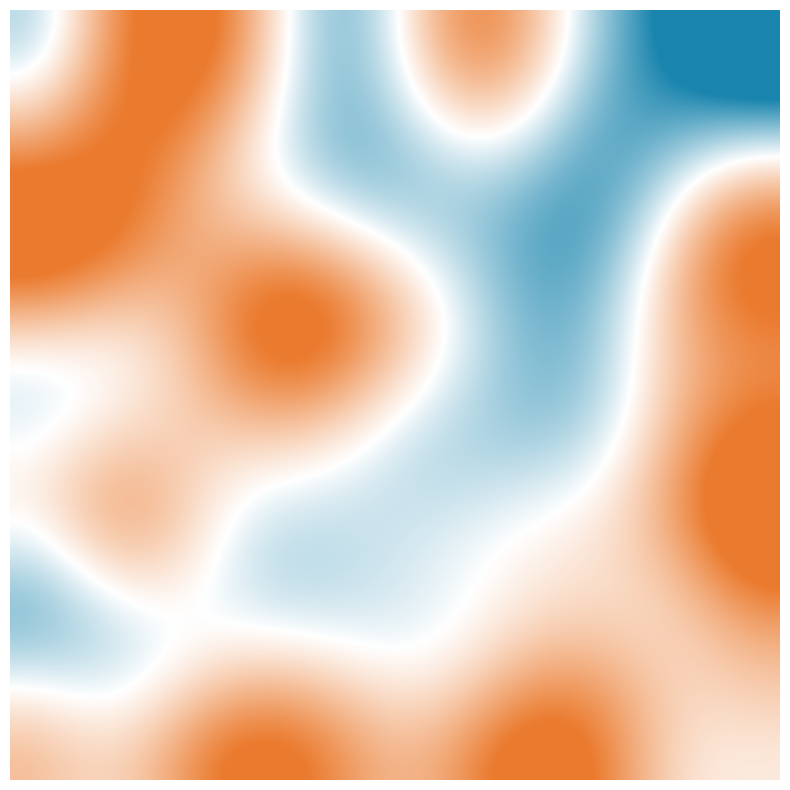

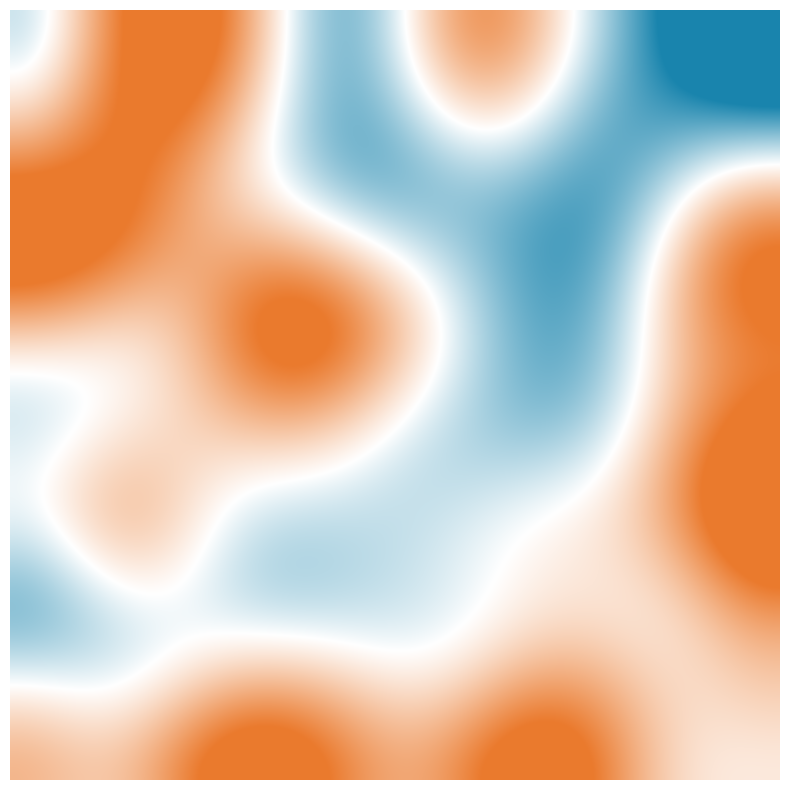

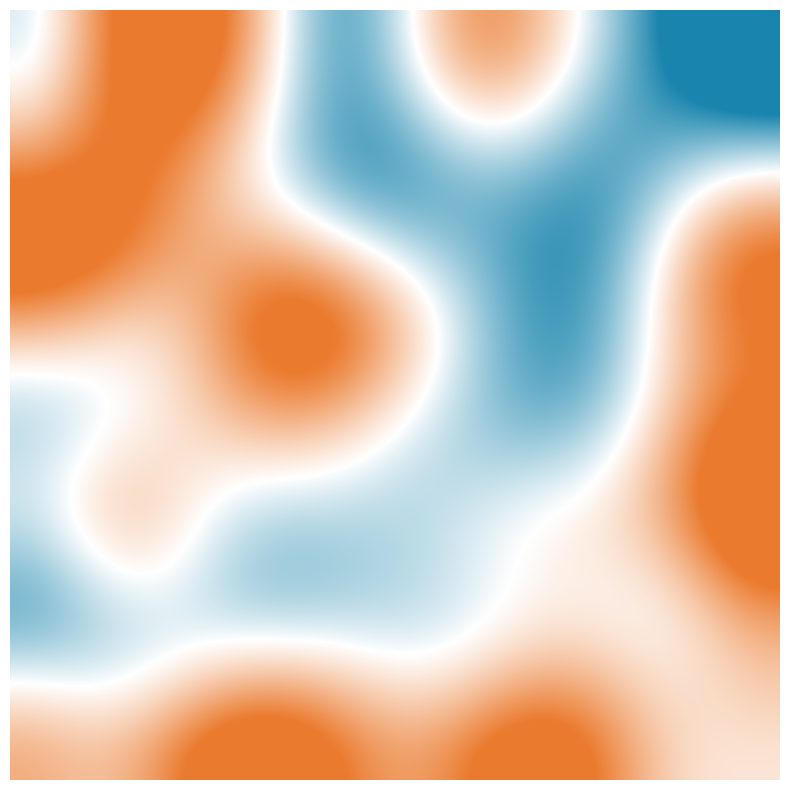

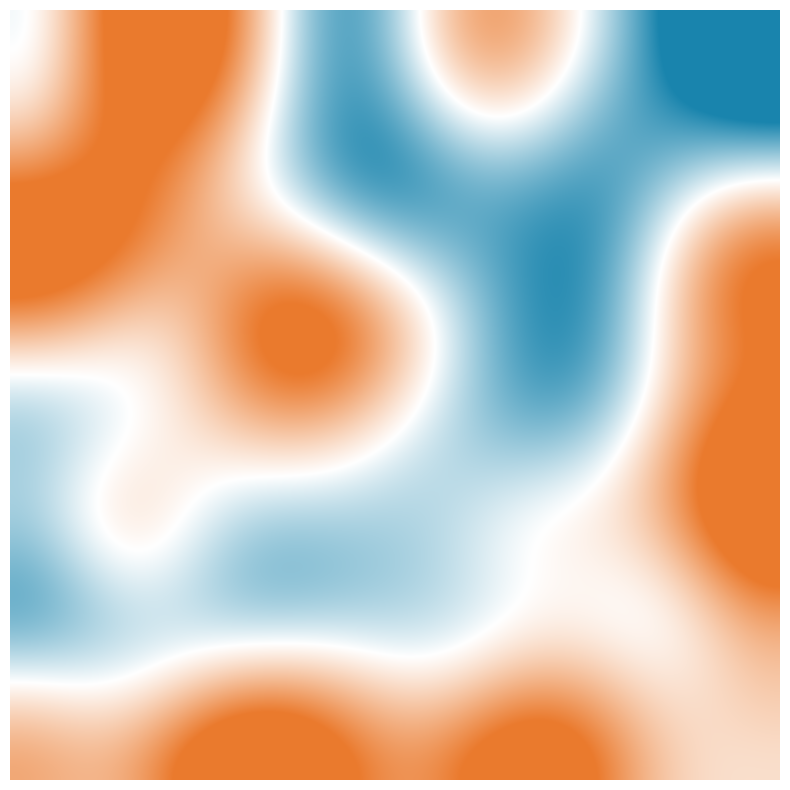

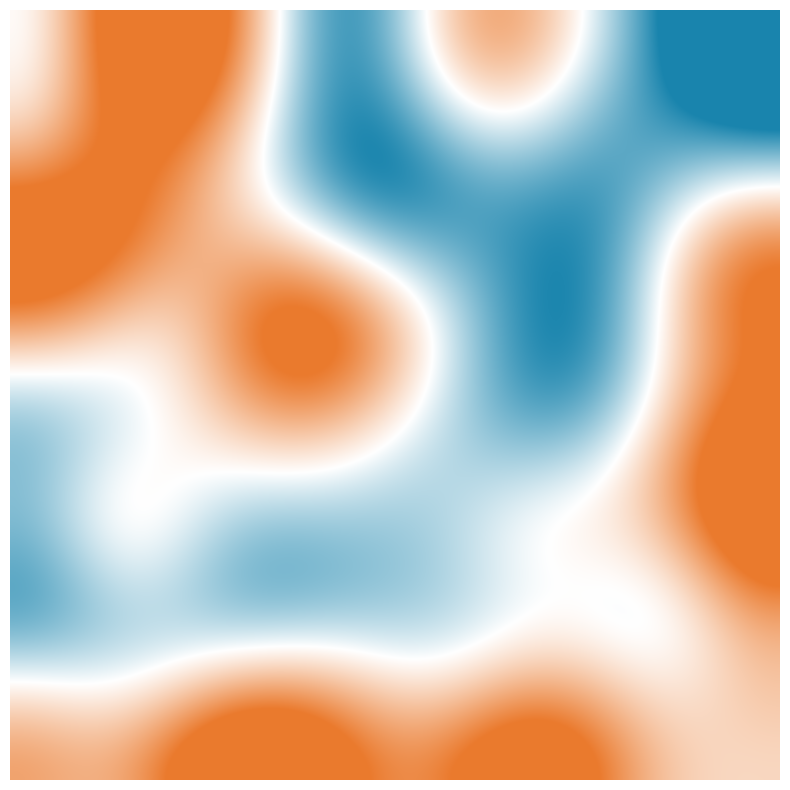

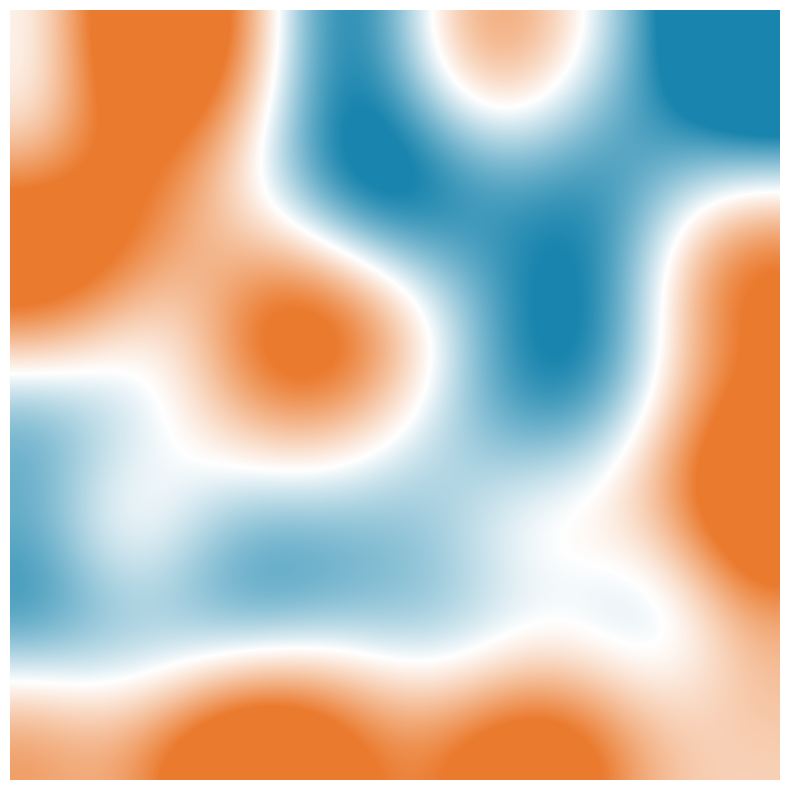

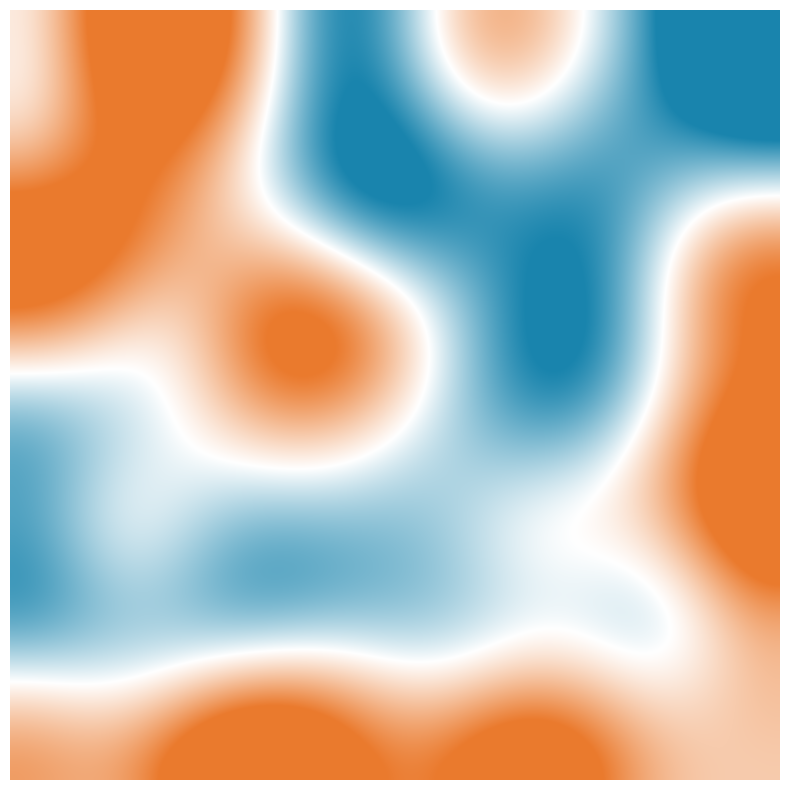

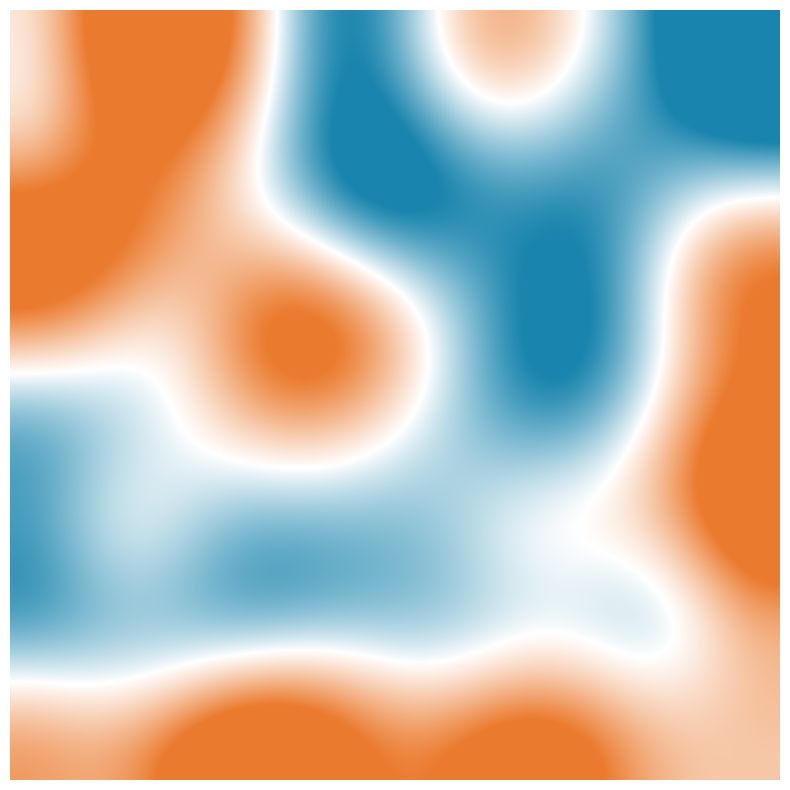

In [4]:
for i in range(motion1.shape[2]):
    result = motion_to_posneg_image(motion1[...,i, 0],vmax=10)
    plt.figure(figsize=(8, 8))
    plt.imshow(result)
    plt.axis("off")
    plt.margins(0)
    plt.tight_layout()
    plt.savefig(f"/home/cyf/wbi/Virginia/code_for_paper/Fig2/2.1_simulation/pipeline_fig/slice_motion/motions_slice{i}.png", dpi=600, bbox_inches="tight", pad_inches=0)